This notebook will be used for computing the confidence interval of a gpt-2 model's outputs when initialized with different weights.
The benchmark we will be looking at will be the babylm


In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from pathlib import Path
import pandas as pd

SRC = Path("/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/fast_eval/ewok_fast")          # adjust path if needed

ewok_df = pd.concat(
    [
        pd.read_json(fp, lines=True, encoding="utf-8")
        #   .assign(file=fp.name, category=fp.stem)  # metadata
        for fp in SRC.glob("*.jsonl")              # use rglob("*.jsonl") if nested
    ],
    ignore_index=True,
    sort=False,    # keep union of columns
)

# optional niceties
ewok_df = ewok_df.convert_dtypes()
ewok_df

,Domain,ConceptA,ConceptB,ContextType,ContextDiff,TargetDiff,Context1,Context2,Target1,Target2
0,material-properties,fragile,sturdy,direct,antonym,concept swap,Jesse applied pressure to the balloon. It rema...,Jesse applied pressure to the balloon. It broke.,The balloon is sturdy.,The balloon is fragile.
1,material-properties,transparent,opaque,direct,negation,concept swap,Chao cannot see through the wheel.,Chao can see through the wheel.,The wheel is opaque.,The wheel is transparent.
2,material-properties,soft,hard,indirect,material,concept swap,The bin is made of jelly.,The bin is made of glass.,The bin is soft.,The bin is hard.
3,material-properties,soft,hard,indirect,material,concept swap,The balloon is made of terracotta.,The balloon is made of fabric.,The surface of the balloon is hard.,The surface of the balloon is soft.
4,material-properties,heavy,light,direct,antonym,concept swap,The balloon weighs a lot.,The balloon weighs little.,The balloon is heavy.,The balloon is light.
...,...,...,...,...,...,...,...,...,...,...
1095,material-dynamics,drape,stir,indirect,material,concept swap,Ali sees the propane.,Ali sees the twill.,Ali stirs it.,Ali drapes it.
1096,material-dynamics,drape,stir,direct,material,concept swap,Chao sees something that is liquid.,Chao sees something that is fabric.,Chao stirs it.,Chao drapes it.
1097,material-dynamics,squeeze,stir,indirect,material,concept swap,Mohammed sees the nitrogen.,Mohammed sees the play-doh.,Mohammed stirs it.,Mohammed squeezes it.
1098,material-dynamics,break,drip,indirect,material,concept swap,Chao sees the water.,Chao sees the feather.,It drips.,It breaks.


In [2]:
model_path = 'Jorgeis1/babygpt-10m-trial_run_Oc6th_BTSZ_16_sid19'
model_path = 'openai-community/gpt2-xl'
tokenizer = AutoTokenizer.from_pretrained(model_path)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.device

device(type='cuda', index=0)

In [3]:
import io
from contextlib import redirect_stdout, redirect_stderr

def capture_output(fn, *args, **kwargs):
    buf = io.StringIO()
    with redirect_stdout(buf), redirect_stderr(buf):
        result = fn(*args, **kwargs)
    return result, buf.getvalue()

# usage
def f(n):
    for i in range(n):
        print(i)
    return n*n

val, out = capture_output(f, 3)
# val == 9, out == "0\n1\n2\n"
val, out 

(9, '0\n1\n2\n')

In [4]:
import os 
os.getcwd()
#default path is '/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_pipeline/sentence_zero_shot'
if os.getcwd() == '/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_pipeline/sentence_zero_shot':
    os.chdir('/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/') 
else:
    os.chdir('/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_pipeline/sentence_zero_shot')

In [5]:
# Run the repo's exact pipeline codepaths inside the notebook (faithful reproduction)
# Run the repo's exact pipeline codepaths inside the notebook (faithful reproduction)
from types import SimpleNamespace
from pathlib import Path
from evaluation_pipeline.sentence_zero_shot.dataset import get_dataloader
# from dataset import get_dataloader
from evaluation_pipeline.sentence_zero_shot.compute_results import compute_results
# from compute_results import compute_results
# from evaluation_pipeline.sentence_zero_shot.run import process_results, create_evaluation_report
from evaluation_pipeline.sentence_zero_shot.run import process_results, create_evaluation_report





In [6]:
print(out)
import re

def extract_accuracies(report: str, *, lowercase_keys: bool = True) -> dict[str, float]:
    """
    Parse a report string and return { category_or_domain: accuracy_float }.

    - Captures any line shaped like:  <label>: <number>
    - Skips section headers (### ...), 'TEMPERATURE: ...', ellipses, and blanks.
    - Leaves keys as-is unless lowercase_keys=True (default), which lowercases them.

    Example keys captured:
      'material-properties', 'social-interactions', 'direct', 'indirect',
      'antonym', 'variable swap', etc.
    """
    accuracies: dict[str, float] = {}
    for raw in report.splitlines():
        line = raw.strip()
        if not line or line.startswith("###") or line.startswith("..."):
            continue
        if line.upper().startswith("TEMPERATURE:"):
            continue

        m = re.match(r"^([A-Za-z][A-Za-z0-9 _\-]+?)\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*$", line)
        if not m:
            # This also skips the final "AVERAGE ACCURACY" number (no colon)
            continue

        key, val = m.group(1).strip(), float(m.group(2))
        if lowercase_keys:
            key = key.lower()
        accuracies[key] = val

    return accuracies



0
1
2



In [7]:


model_paths = []
model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc6th_BTSZ_16_sid19')
model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc6th_BTSZ_16_sid58')
model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc6th_BTSZ_16_sid121')
model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc6th_BTSZ_16_sid123')
model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc6th_BTSZ_16_sid79')

# model_path = 'openai-community/gpt2-xl'
total_accuracies = {}

for model_path in model_paths:
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(model_path)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.device

    args = SimpleNamespace(
        data_path=Path("/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/fast_eval/ewok_fast"),
        output_dir=Path("/tmp"),
        task="ewok",
        model_path_or_name=model_path,
        backend="causal",
        min_temperature=1.0,
        max_temperature=None,
        temperature_interval=0.05,
        batch_size=64,
        non_causal_batch_size=64,
        full_sentence_scores=False,
        save_predictions=False,
        revision_name="main",
    )

    model_name = model_path 


    dataloader = get_dataloader(args)
    temperatures = [1.0]
    results, _ = compute_results(args, model, dataloader, temperatures)
    accuracies, average_accuracies = process_results(args, results)

    # create_evaluation_report(1.0, average_accuracies[1.0], accuracies[1.0])
    #we try capturing the output
    val, out = capture_output(create_evaluation_report, 1.0, average_accuracies[1.0], accuracies[1.0])
    print(out)
    ewok_accuracies = extract_accuracies(out)
    print(ewok_accuracies)
    for k, v in ewok_accuracies.items():
        total_accuracies[f"{k}"] = total_accuracies.get(f"{k}", [])
        total_accuracies[f"{k}"].append( v)
    total_accuracies

100%|██████████| 18/18 [00:01<00:00,  9.10it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 46.00
social-interactions: 52.00
social-relations: 50.00
spatial-relations: 41.00
quantitative-properties: 54.00
physical-dynamics: 45.00
agent-properties: 52.00
social-properties: 56.00
physical-relations: 57.00
physical-interactions: 43.00
material-dynamics: 45.00

### CONTEXT_TYPE ACCURACY
direct: 49.69
indirect: 48.77

### CONTEXT_CONTRAST ACCURACY
antonym: 47.67
negation: 60.53
material: 44.60
variable swap: 51.18
other: 56.79
active-passive: 66.67
number: 50.00
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 48.91
variable swap: 50.22

### AVERAGE ACCURACY
49.18


{'material-properties': 46.0, 'social-interactions': 52.0, 'social-relations': 50.0, 'spatial-relations': 41.0, 'quantitative-properties': 54.0, 'physical-dynamics': 45.0, 'agent-properties': 52.0, 'social-properties': 56.0, 'physical-relations': 57.0, 'physical-interactions': 43.0, 'material-dynamics': 45.0, 'direct': 49.69, 'indirect': 48.77, 'a

100%|██████████| 18/18 [00:01<00:00, 11.61it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 46.00
social-interactions: 55.00
social-relations: 48.00
spatial-relations: 41.00
quantitative-properties: 50.00
physical-dynamics: 48.00
agent-properties: 54.00
social-properties: 54.00
physical-relations: 53.00
physical-interactions: 44.00
material-dynamics: 43.00

### CONTEXT_TYPE ACCURACY
direct: 50.71
indirect: 47.13

### CONTEXT_CONTRAST ACCURACY
antonym: 47.33
negation: 60.53
material: 43.17
variable swap: 52.61
other: 55.56
active-passive: 66.67
number: 40.91
variable_swap: 33.33

### TARGET_CONTRAST ACCURACY
concept swap: 47.88
variable swap: 51.98

### AVERAGE ACCURACY
48.73


{'material-properties': 46.0, 'social-interactions': 55.0, 'social-relations': 48.0, 'spatial-relations': 41.0, 'quantitative-properties': 50.0, 'physical-dynamics': 48.0, 'agent-properties': 54.0, 'social-properties': 54.0, 'physical-relations': 53.0, 'physical-interactions': 44.0, 'material-dynamics': 43.0, 'direct': 50.71, 'indirect': 47.13, 'a

100%|██████████| 18/18 [00:01<00:00, 11.01it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 46.00
social-interactions: 49.00
social-relations: 44.00
spatial-relations: 39.00
quantitative-properties: 59.00
physical-dynamics: 47.00
agent-properties: 47.00
social-properties: 53.00
physical-relations: 59.00
physical-interactions: 49.00
material-dynamics: 41.00

### CONTEXT_TYPE ACCURACY
direct: 48.88
indirect: 48.11

### CONTEXT_CONTRAST ACCURACY
antonym: 46.67
negation: 60.53
material: 41.73
variable swap: 50.24
other: 56.79
active-passive: 66.67
number: 63.64
variable_swap: 66.67

### TARGET_CONTRAST ACCURACY
concept swap: 48.57
variable swap: 48.02

### AVERAGE ACCURACY
48.45


{'material-properties': 46.0, 'social-interactions': 49.0, 'social-relations': 44.0, 'spatial-relations': 39.0, 'quantitative-properties': 59.0, 'physical-dynamics': 47.0, 'agent-properties': 47.0, 'social-properties': 53.0, 'physical-relations': 59.0, 'physical-interactions': 49.0, 'material-dynamics': 41.0, 'direct': 48.88, 'indirect': 48.11, 'a

100%|██████████| 18/18 [00:01<00:00, 11.44it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 46.00
social-interactions: 53.00
social-relations: 51.00
spatial-relations: 48.00
quantitative-properties: 45.00
physical-dynamics: 42.00
agent-properties: 50.00
social-properties: 56.00
physical-relations: 53.00
physical-interactions: 42.00
material-dynamics: 45.00

### CONTEXT_TYPE ACCURACY
direct: 49.90
indirect: 46.96

### CONTEXT_CONTRAST ACCURACY
antonym: 46.83
negation: 60.53
material: 44.60
variable swap: 51.66
other: 51.85
active-passive: 100.00
number: 36.36
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 47.65
variable swap: 50.66

### AVERAGE ACCURACY
48.27


{'material-properties': 46.0, 'social-interactions': 53.0, 'social-relations': 51.0, 'spatial-relations': 48.0, 'quantitative-properties': 45.0, 'physical-dynamics': 42.0, 'agent-properties': 50.0, 'social-properties': 56.0, 'physical-relations': 53.0, 'physical-interactions': 42.0, 'material-dynamics': 45.0, 'direct': 49.9, 'indirect': 46.96, 'a

100%|██████████| 18/18 [00:01<00:00, 11.75it/s]

TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 48.00
social-interactions: 54.00
social-relations: 55.00
spatial-relations: 45.00
quantitative-properties: 52.00
physical-dynamics: 46.00
agent-properties: 48.00
social-properties: 55.00
physical-relations: 60.00
physical-interactions: 48.00
material-dynamics: 43.00

### CONTEXT_TYPE ACCURACY
direct: 50.71
indirect: 50.08

### CONTEXT_CONTRAST ACCURACY
antonym: 49.17
negation: 60.53
material: 43.88
variable swap: 55.45
other: 54.32
active-passive: 100.00
number: 40.91
variable_swap: 33.33

### TARGET_CONTRAST ACCURACY
concept swap: 49.60
variable swap: 53.30

### AVERAGE ACCURACY
50.36


{'material-properties': 48.0, 'social-interactions': 54.0, 'social-relations': 55.0, 'spatial-relations': 45.0, 'quantitative-properties': 52.0, 'physical-dynamics': 46.0, 'agent-properties': 48.0, 'social-properties': 55.0, 'physical-relations': 60.0, 'physical-interactions': 48.0, 'material-dynamics': 43.0, 'direct': 50.71, 'indirect': 50.08, '

In [ ]:
def compute_dictionary(model_paths):
    "Given a set of model paths, compute the results dictionary."
    results_dict = {}
    for model_path in model_paths:
        print(f"Processing model at {model_path}...")
        tokenizer = AutoTokenizer.from_pretrained(model_path)
        tokenizer.pad_token = tokenizer.eos_token

        model = AutoModelForCausalLM.from_pretrained(model_path)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model.to(device)


        args = SimpleNamespace(
            data_path=Path("/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/fast_eval/ewok_fast"),
            output_dir=Path("/tmp"),
            task="ewok",
            model_path_or_name=model_path,
            backend="causal",
            min_temperature=1.0,
            max_temperature=None,
            temperature_interval=0.05,
            batch_size=64,
            non_causal_batch_size=64,
            full_sentence_scores=False,
            save_predictions=False,
            revision_name="main",
        )
        dataloader = get_dataloader(args, tokenizer)
        temp = [1.0]
        results, _ = compute_results(args, model, dataloader, temp)
        accuracies, average_accuracies = process_results(args, results)
        val, out = capture_output(create_evaluation_report, 1.0, average_accuracies[1.0], accuracies[1.0])
        ewok_accuracies = extract_accuracies(out)
        for k, v in ewok_accuracies.items():
            results_dict[f"{k}"] = results_dict.get(f"{k}", [])
            results_dict[f"{k}"].append( v)
    return results_dict


In [8]:
batch_size_8_model_paths = []
batch_size_8_model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_8_19')
batch_size_8_model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_8_123')
batch_size_8_model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_8_57')
batch_size_8_model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_8_79')
batch_size_8_model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_8_121')
#we try with batch size 8 models
batch_size_8_accuracies = {}
#for each model in the list, we run the ewok evaluation
for model_path in batch_size_8_model_paths:
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(model_path)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.device

    args = SimpleNamespace(
        data_path=Path("/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/fast_eval/ewok_fast"),
        output_dir=Path("/tmp"),
        task="ewok",
        model_path_or_name=model_path,
        backend="causal",
        min_temperature=1.0,
        max_temperature=None,
        temperature_interval=0.05,
        batch_size=8,
        non_causal_batch_size=8,
        full_sentence_scores=False,
        save_predictions=False,
        revision_name="main",
    )

    model_name = model_path 


    dataloader = get_dataloader(args)
    temperatures = [1.0]
    results, _ = compute_results(args, model, dataloader, temperatures)
    accuracies, average_accuracies = process_results(args, results)

    # create_evaluation_report(1.0, average_accuracies[1.0], accuracies[1.0])
    #we try capturing the output
    val, out = capture_output(create_evaluation_report, 1.0, average_accuracies[1.0], accuracies[1.0])
    print(out)
    ewok_accuracies = extract_accuracies(out)
    print(ewok_accuracies)
    for k, v in ewok_accuracies.items():
        batch_size_8_accuracies[f"{k}"] = batch_size_8_accuracies.get(f"{k}", [])
        batch_size_8_accuracies[f"{k}"].append( v)
    batch_size_8_accuracies


100%|██████████| 138/138 [00:04<00:00, 31.43it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 45.00
social-interactions: 52.00
social-relations: 49.00
spatial-relations: 44.00
quantitative-properties: 46.00
physical-dynamics: 46.00
agent-properties: 49.00
social-properties: 56.00
physical-relations: 57.00
physical-interactions: 47.00
material-dynamics: 45.00

### CONTEXT_TYPE ACCURACY
direct: 48.68
indirect: 48.77

### CONTEXT_CONTRAST ACCURACY
antonym: 47.50
negation: 60.53
material: 46.76
variable swap: 51.66
other: 54.32
active-passive: 66.67
number: 22.73
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 48.45
variable swap: 49.78

### AVERAGE ACCURACY
48.73


{'material-properties': 45.0, 'social-interactions': 52.0, 'social-relations': 49.0, 'spatial-relations': 44.0, 'quantitative-properties': 46.0, 'physical-dynamics': 46.0, 'agent-properties': 49.0, 'social-properties': 56.0, 'physical-relations': 57.0, 'physical-interactions': 47.0, 'material-dynamics': 45.0, 'direct': 48.68, 'indirect': 48.77, 'a

100%|██████████| 138/138 [00:04<00:00, 32.54it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 42.00
social-interactions: 52.00
social-relations: 55.00
spatial-relations: 49.00
quantitative-properties: 50.00
physical-dynamics: 49.00
agent-properties: 51.00
social-properties: 55.00
physical-relations: 55.00
physical-interactions: 43.00
material-dynamics: 45.00

### CONTEXT_TYPE ACCURACY
direct: 50.10
indirect: 49.26

### CONTEXT_CONTRAST ACCURACY
antonym: 47.83
negation: 60.53
material: 44.60
variable swap: 53.55
other: 58.02
active-passive: 66.67
number: 40.91
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 49.14
variable swap: 51.54

### AVERAGE ACCURACY
49.64


{'material-properties': 42.0, 'social-interactions': 52.0, 'social-relations': 55.0, 'spatial-relations': 49.0, 'quantitative-properties': 50.0, 'physical-dynamics': 49.0, 'agent-properties': 51.0, 'social-properties': 55.0, 'physical-relations': 55.0, 'physical-interactions': 43.0, 'material-dynamics': 45.0, 'direct': 50.1, 'indirect': 49.26, 'an

100%|██████████| 138/138 [00:04<00:00, 29.42it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 47.00
social-interactions: 51.00
social-relations: 48.00
spatial-relations: 43.00
quantitative-properties: 60.00
physical-dynamics: 46.00
agent-properties: 47.00
social-properties: 54.00
physical-relations: 50.00
physical-interactions: 46.00
material-dynamics: 43.00

### CONTEXT_TYPE ACCURACY
direct: 50.10
indirect: 47.45

### CONTEXT_CONTRAST ACCURACY
antonym: 46.33
negation: 60.53
material: 46.76
variable swap: 49.29
other: 56.79
active-passive: 66.67
number: 63.64
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 48.91
variable swap: 47.58

### AVERAGE ACCURACY
48.64


{'material-properties': 47.0, 'social-interactions': 51.0, 'social-relations': 48.0, 'spatial-relations': 43.0, 'quantitative-properties': 60.0, 'physical-dynamics': 46.0, 'agent-properties': 47.0, 'social-properties': 54.0, 'physical-relations': 50.0, 'physical-interactions': 46.0, 'material-dynamics': 43.0, 'direct': 50.1, 'indirect': 47.45, 'an

100%|██████████| 138/138 [00:05<00:00, 26.96it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 47.00
social-interactions: 53.00
social-relations: 50.00
spatial-relations: 38.00
quantitative-properties: 57.00
physical-dynamics: 47.00
agent-properties: 53.00
social-properties: 57.00
physical-relations: 57.00
physical-interactions: 41.00
material-dynamics: 47.00

### CONTEXT_TYPE ACCURACY
direct: 49.49
indirect: 49.92

### CONTEXT_CONTRAST ACCURACY
antonym: 48.67
negation: 57.89
material: 46.76
variable swap: 51.66
other: 55.56
active-passive: 66.67
number: 45.45
variable_swap: 33.33

### TARGET_CONTRAST ACCURACY
concept swap: 49.14
variable swap: 51.98

### AVERAGE ACCURACY
49.73


{'material-properties': 47.0, 'social-interactions': 53.0, 'social-relations': 50.0, 'spatial-relations': 38.0, 'quantitative-properties': 57.0, 'physical-dynamics': 47.0, 'agent-properties': 53.0, 'social-properties': 57.0, 'physical-relations': 57.0, 'physical-interactions': 41.0, 'material-dynamics': 47.0, 'direct': 49.49, 'indirect': 49.92, 'a

100%|██████████| 138/138 [00:04<00:00, 28.60it/s]

TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 47.00
social-interactions: 46.00
social-relations: 48.00
spatial-relations: 44.00
quantitative-properties: 59.00
physical-dynamics: 51.00
agent-properties: 52.00
social-properties: 54.00
physical-relations: 54.00
physical-interactions: 41.00
material-dynamics: 47.00

### CONTEXT_TYPE ACCURACY
direct: 49.90
indirect: 48.93

### CONTEXT_CONTRAST ACCURACY
antonym: 47.67
negation: 60.53
material: 46.04
variable swap: 49.76
other: 56.79
active-passive: 66.67
number: 59.09
variable_swap: 66.67

### TARGET_CONTRAST ACCURACY
concept swap: 49.26
variable swap: 49.78

### AVERAGE ACCURACY
49.36


{'material-properties': 47.0, 'social-interactions': 46.0, 'social-relations': 48.0, 'spatial-relations': 44.0, 'quantitative-properties': 59.0, 'physical-dynamics': 51.0, 'agent-properties': 52.0, 'social-properties': 54.0, 'physical-relations': 54.0, 'physical-interactions': 41.0, 'material-dynamics': 47.0, 'direct': 49.9, 'indirect': 48.93, 'an

In [9]:
gutenberg_model_paths = []
gutenberg_model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_SID16_121')
gutenberg_model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_SID16_123')
gutenberg_model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_SID16_19')
gutenberg_model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_SID16_57')
gutenberg_model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_SID16_79')

#we try with gutenberg models
gutenberg_accuracies = {}
#for each model in the list, we run the ewok evaluation
for model_path in gutenberg_model_paths:
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(model_path)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.device

    args = SimpleNamespace(
        data_path=Path("/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/fast_eval/ewok_fast"),
        output_dir=Path("/tmp"),
        task="ewok",
        model_path_or_name=model_path,
        backend="causal",
        min_temperature=1.0,
        max_temperature=None,
        temperature_interval=0.05,
        batch_size=8,
        non_causal_batch_size=8,
        full_sentence_scores=False,
        save_predictions=False,
        revision_name="main",
    )

    model_name = model_path 


    dataloader = get_dataloader(args)
    temperatures = [1.0]
    results, _ = compute_results(args, model, dataloader, temperatures)
    accuracies, average_accuracies = process_results(args, results)

    # create_evaluation_report(1.0, average_accuracies[1.0], accuracies[1.0])
    #we try capturing the output
    val, out = capture_output(create_evaluation_report, 1.0, average_accuracies[1.0], accuracies[1.0])
    print(out)
    ewok_accuracies = extract_accuracies(out)

    print(ewok_accuracies)
    for k, v in ewok_accuracies.items():
        gutenberg_accuracies[f"{k}"] = gutenberg_accuracies.get(f"{k}", [])
        gutenberg_accuracies[f"{k}"].append( v)

100%|██████████| 138/138 [00:05<00:00, 27.12it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 50.00
social-interactions: 54.00
social-relations: 56.00
spatial-relations: 48.00
quantitative-properties: 44.00
physical-dynamics: 50.00
agent-properties: 52.00
social-properties: 55.00
physical-relations: 54.00
physical-interactions: 48.00
material-dynamics: 49.00

### CONTEXT_TYPE ACCURACY
direct: 51.32
indirect: 50.57

### CONTEXT_CONTRAST ACCURACY
antonym: 49.00
negation: 57.89
material: 48.20
variable swap: 55.45
other: 55.56
active-passive: 66.67
number: 45.45
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 49.37
variable swap: 56.83

### AVERAGE ACCURACY
50.91


{'material-properties': 50.0, 'social-interactions': 54.0, 'social-relations': 56.0, 'spatial-relations': 48.0, 'quantitative-properties': 44.0, 'physical-dynamics': 50.0, 'agent-properties': 52.0, 'social-properties': 55.0, 'physical-relations': 54.0, 'physical-interactions': 48.0, 'material-dynamics': 49.0, 'direct': 51.32, 'indirect': 50.57, 'a

100%|██████████| 138/138 [00:05<00:00, 26.82it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 49.00
social-interactions: 58.00
social-relations: 50.00
spatial-relations: 53.00
quantitative-properties: 44.00
physical-dynamics: 46.00
agent-properties: 53.00
social-properties: 54.00
physical-relations: 55.00
physical-interactions: 46.00
material-dynamics: 46.00

### CONTEXT_TYPE ACCURACY
direct: 49.69
indirect: 50.90

### CONTEXT_CONTRAST ACCURACY
antonym: 49.50
negation: 60.53
material: 46.04
variable swap: 54.50
other: 53.09
active-passive: 66.67
number: 31.82
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 49.26
variable swap: 54.63

### AVERAGE ACCURACY
50.36


{'material-properties': 49.0, 'social-interactions': 58.0, 'social-relations': 50.0, 'spatial-relations': 53.0, 'quantitative-properties': 44.0, 'physical-dynamics': 46.0, 'agent-properties': 53.0, 'social-properties': 54.0, 'physical-relations': 55.0, 'physical-interactions': 46.0, 'material-dynamics': 46.0, 'direct': 49.69, 'indirect': 50.9, 'an

100%|██████████| 138/138 [00:05<00:00, 27.47it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 51.00
social-interactions: 57.00
social-relations: 56.00
spatial-relations: 51.00
quantitative-properties: 46.00
physical-dynamics: 48.00
agent-properties: 49.00
social-properties: 53.00
physical-relations: 58.00
physical-interactions: 48.00
material-dynamics: 47.00

### CONTEXT_TYPE ACCURACY
direct: 52.55
indirect: 50.25

### CONTEXT_CONTRAST ACCURACY
antonym: 49.67
negation: 55.26
material: 48.20
variable swap: 56.87
other: 55.56
active-passive: 66.67
number: 36.36
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 50.86
variable swap: 52.86

### AVERAGE ACCURACY
51.27


{'material-properties': 51.0, 'social-interactions': 57.0, 'social-relations': 56.0, 'spatial-relations': 51.0, 'quantitative-properties': 46.0, 'physical-dynamics': 48.0, 'agent-properties': 49.0, 'social-properties': 53.0, 'physical-relations': 58.0, 'physical-interactions': 48.0, 'material-dynamics': 47.0, 'direct': 52.55, 'indirect': 50.25, 'a

100%|██████████| 138/138 [00:04<00:00, 32.73it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 46.00
social-interactions: 57.00
social-relations: 49.00
spatial-relations: 48.00
quantitative-properties: 48.00
physical-dynamics: 47.00
agent-properties: 52.00
social-properties: 56.00
physical-relations: 51.00
physical-interactions: 49.00
material-dynamics: 51.00

### CONTEXT_TYPE ACCURACY
direct: 49.49
indirect: 51.07

### CONTEXT_CONTRAST ACCURACY
antonym: 48.67
negation: 60.53
material: 49.64
variable swap: 52.13
other: 55.56
active-passive: 66.67
number: 45.45
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 50.06
variable swap: 51.54

### AVERAGE ACCURACY
50.36


{'material-properties': 46.0, 'social-interactions': 57.0, 'social-relations': 49.0, 'spatial-relations': 48.0, 'quantitative-properties': 48.0, 'physical-dynamics': 47.0, 'agent-properties': 52.0, 'social-properties': 56.0, 'physical-relations': 51.0, 'physical-interactions': 49.0, 'material-dynamics': 51.0, 'direct': 49.49, 'indirect': 51.07, 'a

100%|██████████| 138/138 [00:04<00:00, 32.54it/s]

TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 47.00
social-interactions: 55.00
social-relations: 55.00
spatial-relations: 48.00
quantitative-properties: 44.00
physical-dynamics: 49.00
agent-properties: 56.00
social-properties: 51.00
physical-relations: 53.00
physical-interactions: 48.00
material-dynamics: 51.00

### CONTEXT_TYPE ACCURACY
direct: 49.69
indirect: 51.40

### CONTEXT_CONTRAST ACCURACY
antonym: 49.33
negation: 55.26
material: 51.08
variable swap: 54.03
other: 51.85
active-passive: 66.67
number: 36.36
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 49.48
variable swap: 55.07

### AVERAGE ACCURACY
50.64


{'material-properties': 47.0, 'social-interactions': 55.0, 'social-relations': 55.0, 'spatial-relations': 48.0, 'quantitative-properties': 44.0, 'physical-dynamics': 49.0, 'agent-properties': 56.0, 'social-properties': 51.0, 'physical-relations': 53.0, 'physical-interactions': 48.0, 'material-dynamics': 51.0, 'direct': 49.69, 'indirect': 51.4, 'an

In [10]:
total_accuracies

{'material-properties': [46.0, 46.0, 46.0, 46.0, 48.0],
 'social-interactions': [52.0, 55.0, 49.0, 53.0, 54.0],
 'social-relations': [50.0, 48.0, 44.0, 51.0, 55.0],
 'spatial-relations': [41.0, 41.0, 39.0, 48.0, 45.0],
 'quantitative-properties': [54.0, 50.0, 59.0, 45.0, 52.0],
 'physical-dynamics': [45.0, 48.0, 47.0, 42.0, 46.0],
 'agent-properties': [52.0, 54.0, 47.0, 50.0, 48.0],
 'social-properties': [56.0, 54.0, 53.0, 56.0, 55.0],
 'physical-relations': [57.0, 53.0, 59.0, 53.0, 60.0],
 'physical-interactions': [43.0, 44.0, 49.0, 42.0, 48.0],
 'material-dynamics': [45.0, 43.0, 41.0, 45.0, 43.0],
 'direct': [49.69, 50.71, 48.88, 49.9, 50.71],
 'indirect': [48.77, 47.13, 48.11, 46.96, 50.08],
 'antonym': [47.67, 47.33, 46.67, 46.83, 49.17],
 'negation': [60.53, 60.53, 60.53, 60.53, 60.53],
 'material': [44.6, 43.17, 41.73, 44.6, 43.88],
 'variable swap': [50.22, 51.98, 48.02, 50.66, 53.3],
 'other': [56.79, 55.56, 56.79, 51.85, 54.32],
 'active-passive': [66.67, 66.67, 66.67, 100.0, 

In [11]:
gptxl_report = """TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 54.00
social-interactions: 77.00
social-relations: 67.00
spatial-relations: 51.00
quantitative-properties: 64.00
physical-dynamics: 73.00
agent-properties: 56.00
social-properties: 78.00
physical-relations: 56.00
physical-interactions: 51.00
material-dynamics: 63.00

### CONTEXT_TYPE ACCURACY
direct: 68.23
indirect: 58.29

### CONTEXT_CONTRAST ACCURACY
antonym: 62.00
negation: 65.79
material: 63.31
variable swap: 60.19
other: 69.14
active-passive: 100.00
number: 68.18
variable_swap: 66.67

### TARGET_CONTRAST ACCURACY
concept swap: 64.15
variable swap: 57.27

### AVERAGE ACCURACY
62.73"""
gptxl_accuracies = extract_accuracies(gptxl_report)
for k, v in gptxl_accuracies.items():
    gptxl_accuracies[k] = [gptxl_accuracies[k]]

In [12]:
gptxl_accuracies

{'material-properties': [54.0],
 'social-interactions': [77.0],
 'social-relations': [67.0],
 'spatial-relations': [51.0],
 'quantitative-properties': [64.0],
 'physical-dynamics': [73.0],
 'agent-properties': [56.0],
 'social-properties': [78.0],
 'physical-relations': [56.0],
 'physical-interactions': [51.0],
 'material-dynamics': [63.0],
 'direct': [68.23],
 'indirect': [58.29],
 'antonym': [62.0],
 'negation': [65.79],
 'material': [63.31],
 'variable swap': [57.27],
 'other': [69.14],
 'active-passive': [100.0],
 'number': [68.18],
 'variable_swap': [66.67],
 'concept swap': [64.15]}

In [13]:
#babyLM gpt trained on 100M words
gpt_100m_report = """TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 47.00
social-interactions: 53.00
social-relations: 53.00
spatial-relations: 50.00
quantitative-properties: 58.00
physical-dynamics: 47.00
agent-properties: 46.00
social-properties: 56.00
physical-relations: 53.00
physical-interactions: 53.00
material-dynamics: 52.00

### CONTEXT_TYPE ACCURACY
direct: 53.16
indirect: 50.41

### CONTEXT_CONTRAST ACCURACY
antonym: 49.50
negation: 57.89
material: 51.08
variable swap: 53.08
other: 54.32
active-passive: 66.67
number: 68.18
variable_swap: 83.33

### TARGET_CONTRAST ACCURACY
concept swap: 52.00
variable swap: 50.22

### AVERAGE ACCURACY
51.64

"""
gpt_100m_accuracies = extract_accuracies(gpt_100m_report)
for k, v in gpt_100m_accuracies.items():
    gpt_100m_accuracies[k] = [gpt_100m_accuracies[k]]

In [14]:
phi_15_report = """TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 66.00
social-interactions: 81.00
social-relations: 68.00
spatial-relations: 68.00
quantitative-properties: 72.00
physical-dynamics: 71.00
agent-properties: 68.00
social-properties: 73.00
physical-relations: 67.00
physical-interactions: 57.00
material-dynamics: 76.00

### CONTEXT_TYPE ACCURACY
direct: 75.56
indirect: 65.02

### CONTEXT_CONTRAST ACCURACY
antonym: 71.17
negation: 76.32
material: 69.78
variable swap: 66.35
other: 67.90
active-passive: 100.00
number: 45.45
variable_swap: 100.00

### TARGET_CONTRAST ACCURACY
concept swap: 71.36
variable swap: 63.44

### AVERAGE ACCURACY
69.73

"""
phi_15_accuracies = extract_accuracies(phi_15_report)
for k, v in phi_15_accuracies.items():
    phi_15_accuracies[k] = [phi_15_accuracies[k]]

In [15]:
gpt_bert_report = """TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 50.00
social-interactions: 57.00
social-relations: 55.00
spatial-relations: 48.00
quantitative-properties: 57.00
physical-dynamics: 48.00
agent-properties: 49.00
social-properties: 47.00
physical-relations: 53.00
physical-interactions: 46.00
material-dynamics: 43.00

### CONTEXT_TYPE ACCURACY
direct: 52.14
indirect: 48.77

### CONTEXT_CONTRAST ACCURACY
antonym: 49.33
negation: 55.26
material: 43.17
variable swap: 54.03
other: 56.79
active-passive: 33.33
number: 50.00
variable_swap: 66.67

### TARGET_CONTRAST ACCURACY
concept swap: 49.71
variable swap: 52.42

### AVERAGE ACCURACY
50.27
"""
gpt_bert_accuracies = extract_accuracies(gpt_bert_report)
for k, v in gpt_bert_accuracies.items():
    gpt_bert_accuracies[k] = [gpt_bert_accuracies[k]]

In [7]:
total_accuracies

{'material-properties': [46.0, 46.0, 46.0, 46.0, 48.0],
 'social-interactions': [52.0, 55.0, 49.0, 53.0, 54.0],
 'social-relations': [50.0, 48.0, 44.0, 51.0, 55.0],
 'spatial-relations': [41.0, 41.0, 39.0, 48.0, 45.0],
 'quantitative-properties': [54.0, 50.0, 59.0, 45.0, 52.0],
 'physical-dynamics': [45.0, 48.0, 47.0, 42.0, 46.0],
 'agent-properties': [52.0, 54.0, 47.0, 50.0, 48.0],
 'social-properties': [56.0, 54.0, 53.0, 56.0, 55.0],
 'physical-relations': [57.0, 53.0, 59.0, 53.0, 60.0],
 'physical-interactions': [43.0, 44.0, 49.0, 42.0, 48.0],
 'material-dynamics': [45.0, 43.0, 41.0, 45.0, 43.0],
 'direct': [49.69, 50.71, 48.88, 49.9, 50.71],
 'indirect': [48.77, 47.13, 48.11, 46.96, 50.08],
 'antonym': [47.67, 47.33, 46.67, 46.83, 49.17],
 'negation': [60.53, 60.53, 60.53, 60.53, 60.53],
 'material': [44.6, 43.17, 41.73, 44.6, 43.88],
 'variable swap': [50.22, 51.98, 48.02, 50.66, 53.3],
 'other': [56.79, 55.56, 56.79, 51.85, 54.32],
 'active-passive': [66.67, 66.67, 66.67, 100.0, 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def plot_scores_with_ci(scores_dict, confidence_level=0.95):
    """
    Calculates the mean and confidence interval for model scores in different domains
    and plots them as a bar chart with error bars.

    Args:
        scores_dict (dict): A dictionary where keys are domain names (str) and
                            values are lists of scores (float or int).
        confidence_level (float): The desired confidence level for the interval (e.g., 0.95 for 95%).
    """
    domains = list(scores_dict.keys())
    means = []
    ci_errors = []

    for domain in domains:
        scores = scores_dict[domain]
        n = len(scores)
        mean = np.mean(scores)
        means.append(mean)

        # Calculate confidence interval if there's more than one score
        if n > 1:
            # Calculate the standard error of the mean
            sem = stats.sem(scores)
            # Find the t-critical value for the given confidence level
            t_critical = stats.t.ppf((1 + confidence_level) / 2., n - 1)
            # The confidence interval error is the margin of error
            ci_error = t_critical * sem
            ci_errors.append(ci_error)
        else:
            # Cannot compute CI for a single value, so error is 0
            ci_errors.append(0)

    # Plotting
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Create the bar plot
    ax.bar(domains, means, yerr=ci_errors, capsize=5, color='lightblue', ecolor='darkgray')
    #we add horizontal line at y= 50 percent to denote chance level
    ax.axhline(y=50, color='red', linestyle='--', label='Chance Level (50%)')
    # Formatting the plot
    ax.set_ylabel('Mean Score', fontsize=12)
    ax.set_title(' GPT-2 BabyLM Model Mean Scores by Domain with 95% Confidence Interval', fontsize=16)
    plt.xticks(rotation=90) # Rotate domain names for better readability
    ax.set_yticks(np.arange(0, 111, 10)) # Set y-axis ticks in increments of 10
    ax.grid(axis='y', linestyle='--', alpha=0.9)
    
    # Ensure everything fits within the figure
    plt.tight_layout()
    
    # Display the plot
    plt.show()

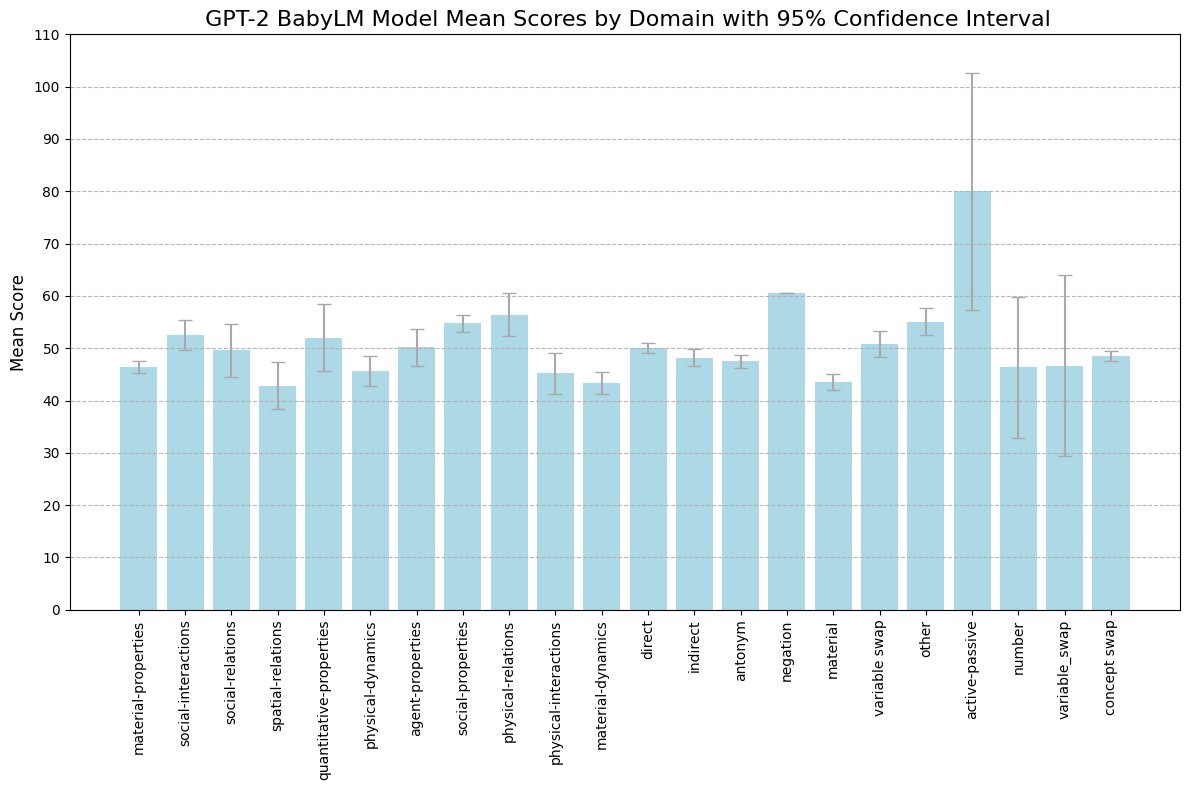

In [8]:


plot_scores_with_ci(total_accuracies)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def plot_scores_with_ci(scores_dict, scores_dict_2=None, model_1_label='Model 1', model_2_label='Model 2', confidence_level=0.95):
    """
    Calculates the mean and confidence interval for model scores in different domains
    and plots them as a bar chart with error bars. Can optionally plot a second model's scores
    side-by-side for comparison.

    Args:
        scores_dict (dict): A dictionary for the first model where keys are domain names (str)
                            and values are lists of scores (float or int).
        scores_dict_2 (dict, optional): An optional dictionary for the second model with the same format.
        model_1_label (str): The label for the first model's data on the plot.
        model_2_label (str): The label for the second model's data on the plot.
        confidence_level (float): The desired confidence level for the interval (e.g., 0.95 for 95%).
    """
    domains = list(scores_dict.keys())
    
    # --- Calculate stats for Model 1 ---
    means_1 = []
    ci_errors_1 = []
    for domain in domains:
        scores = scores_dict.get(domain, [])
        n = len(scores)
        mean = np.mean(scores) if n > 0 else 0
        means_1.append(mean)

        if n > 1:
            sem = stats.sem(scores)
            t_critical = stats.t.ppf((1 + confidence_level) / 2., n - 1)
            ci_error = t_critical * sem
            ci_errors_1.append(ci_error)
        else:
            ci_errors_1.append(0)

    # --- Plotting Setup ---
    x = np.arange(len(domains))  # the label locations
    width = 0.4  # the width of the bars

    fig, ax = plt.subplots(figsize=(15, 8))

    # --- Plot Bars ---
    if scores_dict_2:
        # Adjust width and positions for side-by-side bars
        width = 0.35
        rects1 = ax.bar(x - width/2, means_1, width, yerr=ci_errors_1, label=model_1_label, capsize=4, color='skyblue', ecolor='darkgray')
        
        # Calculate stats for Model 2
        means_2 = []
        ci_errors_2 = []
        for domain in domains:
            scores = scores_dict_2.get(domain, [])
            n = len(scores)
            mean = np.mean(scores) if n > 0 else 0
            means_2.append(mean)

            if n > 1:
                sem = stats.sem(scores)
                t_critical = stats.t.ppf((1 + confidence_level) / 2., n - 1)
                ci_error = t_critical * sem
                ci_errors_2.append(ci_error)
            else:
                ci_errors_2.append(0)
        
        rects2 = ax.bar(x + width/2, means_2, width, yerr=ci_errors_2, label=model_2_label, capsize=4, color='lightcoral', ecolor='darkgray')
    else:
        # Plot a single set of bars if only one dictionary is provided
        rects1 = ax.bar(x, means_1, width, yerr=ci_errors_1, label=model_1_label, capsize=5, color='skyblue', ecolor='darkgray')

    #we add horizontal line at y= 50 percent to denote chance level
    ax.axhline(y=50, color='red', linestyle='--', label='Chance Level (50%)')
    # --- Formatting the plot ---
    ax.set_ylabel('Mean Score', fontsize=12)
    ax.set_title('Model Mean Scores by domain', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(domains, rotation=90)
    ax.set_yticks(np.arange(0, 111, 10))
    ax.grid(axis='y', linestyle='-', alpha=0.8)
    ax.legend()
    
    # Ensure everything fits within the figure
    plt.tight_layout()
    
    # Display the plot
    plt.show()


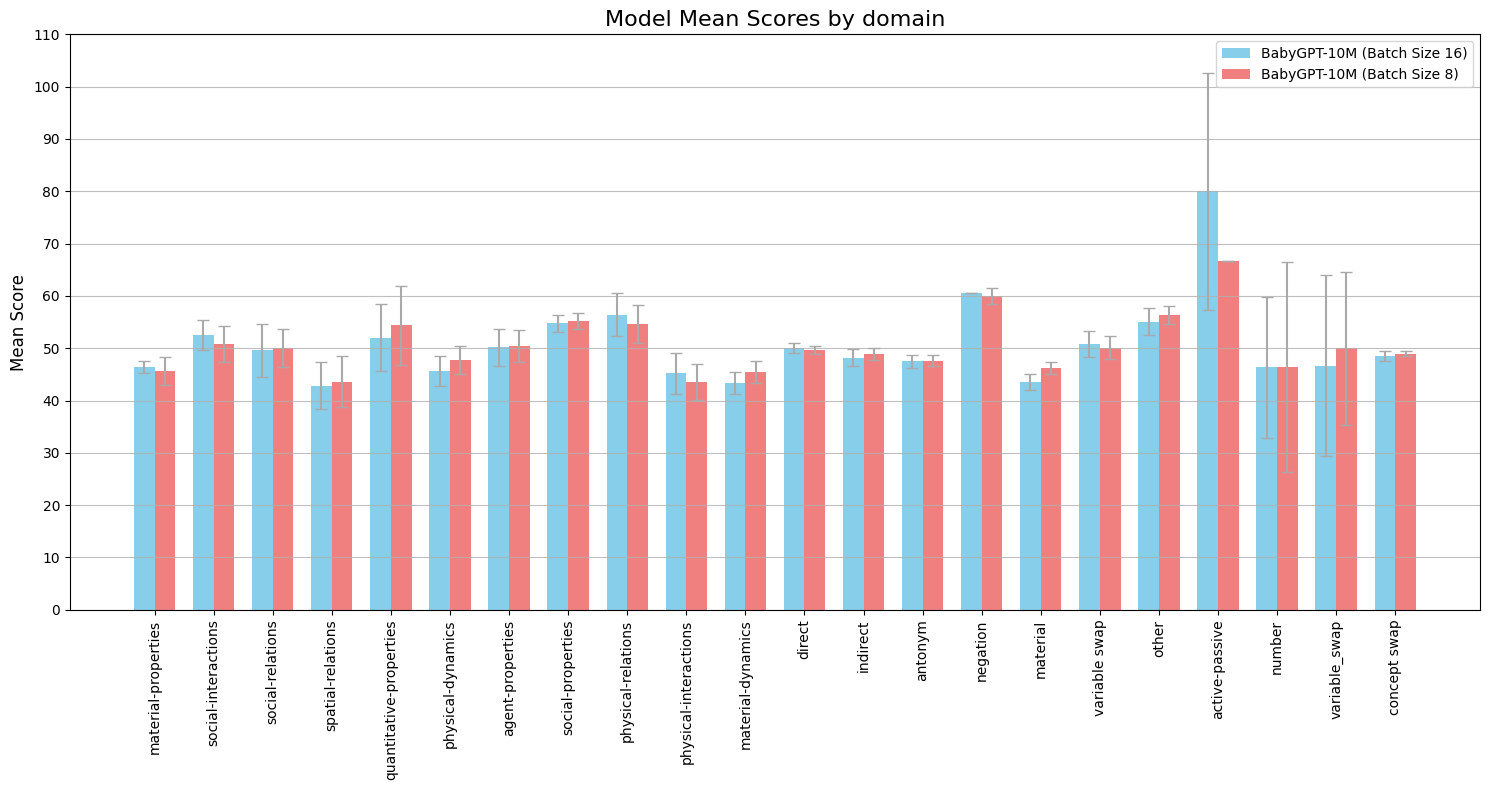

In [20]:
# we compare the confidence intervals between the standard babylm GPT 2 and one with batchsize 8
plot_scores_with_ci(total_accuracies, batch_size_8_accuracies, model_1_label='BabyGPT-10M (Batch Size 16)', model_2_label='BabyGPT-10M (Batch Size 8)')

In [29]:
#we now compare for when the model has a larger hidden size
model_paths_large_hidden = []
model_paths_large_hidden.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_large_8_121')
model_paths_large_hidden.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_large_8_123')
model_paths_large_hidden.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_large_8_19')
model_paths_large_hidden.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_large_8_57')
model_paths_large_hidden.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_large_8_79')
#we try with large hidden size models
large_hidden_accuracies = {}
#for each model in the list, we run the ewok evaluation
for model in model_paths_large_hidden:
    tokenizer = AutoTokenizer.from_pretrained(model)
    tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(model)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.device
    print('model loaded')
    args = SimpleNamespace(
        data_path=Path("/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/fast_eval/ewok_fast"),
        output_dir=Path("/tmp"),
        task="ewok",
        model_path_or_name=model_path,
        backend="causal",
        min_temperature=1.0,
        max_temperature=None,
        temperature_interval=0.05,
        batch_size=8,
        non_causal_batch_size=8,
        full_sentence_scores=False,
        save_predictions=False,
        revision_name="main",
    )
    

    model_name = model 


    dataloader = get_dataloader(args)
    temperatures = [1.0]
    results, _ = compute_results(args, model, dataloader, temperatures)
    accuracies, average_accuracies = process_results(args, results)

    # create_evaluation_report(1.0, average_accuracies[1.0], accuracies[1.0])
    #we try capturing the output
    val, out = capture_output(create_evaluation_report, 1.0, average_accuracies[1.0], accuracies[1.0])
    print(out)
    ewok_accuracies = extract_accuracies(out)
    print(ewok_accuracies)
    for k, v in ewok_accuracies.items():
        large_hidden_accuracies[f"{k}"] = large_hidden_accuracies.get(f"{k}", [])
        large_hidden_accuracies[f"{k}"].append( v)
    large_hidden_accuracies

model loaded


100%|██████████| 138/138 [00:04<00:00, 29.93it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 46.00
social-interactions: 51.00
social-relations: 48.00
spatial-relations: 49.00
quantitative-properties: 57.00
physical-dynamics: 44.00
agent-properties: 54.00
social-properties: 54.00
physical-relations: 54.00
physical-interactions: 41.00
material-dynamics: 45.00

### CONTEXT_TYPE ACCURACY
direct: 49.08
indirect: 49.59

### CONTEXT_CONTRAST ACCURACY
antonym: 47.83
negation: 60.53
material: 44.60
variable swap: 52.13
other: 58.02
active-passive: 33.33
number: 45.45
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 49.26
variable swap: 49.78

### AVERAGE ACCURACY
49.36


{'material-properties': 46.0, 'social-interactions': 51.0, 'social-relations': 48.0, 'spatial-relations': 49.0, 'quantitative-properties': 57.0, 'physical-dynamics': 44.0, 'agent-properties': 54.0, 'social-properties': 54.0, 'physical-relations': 54.0, 'physical-interactions': 41.0, 'material-dynamics': 45.0, 'direct': 49.08, 'indirect': 49.59, 'a

tokenizer_config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/724M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

model loaded


100%|██████████| 138/138 [00:04<00:00, 32.34it/s]

TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 47.00
social-interactions: 51.00
social-relations: 45.00
spatial-relations: 49.00
quantitative-properties: 56.00
physical-dynamics: 47.00
agent-properties: 54.00
social-properties: 55.00
physical-relations: 56.00
physical-interactions: 43.00
material-dynamics: 47.00

### CONTEXT_TYPE ACCURACY
direct: 49.08
indirect: 50.74

### CONTEXT_CONTRAST ACCURACY
antonym: 48.17
negation: 60.53
material: 46.76
variable swap: 52.61
other: 55.56
active-passive: 66.67
number: 54.55
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 50.06
variable swap: 49.78

### AVERAGE ACCURACY
50.00


{'material-properties': 47.0, 'social-interactions': 51.0, 'social-relations': 45.0, 'spatial-relations': 49.0, 'quantitative-properties': 56.0, 'physical-dynamics': 47.0, 'agent-properties': 54.0, 'social-properties': 55.0, 'physical-relations': 56.0, 'physical-interactions': 43.0, 'material-dynamics': 47.0, 'direct': 49.08, 'indirect': 50.74, 'a

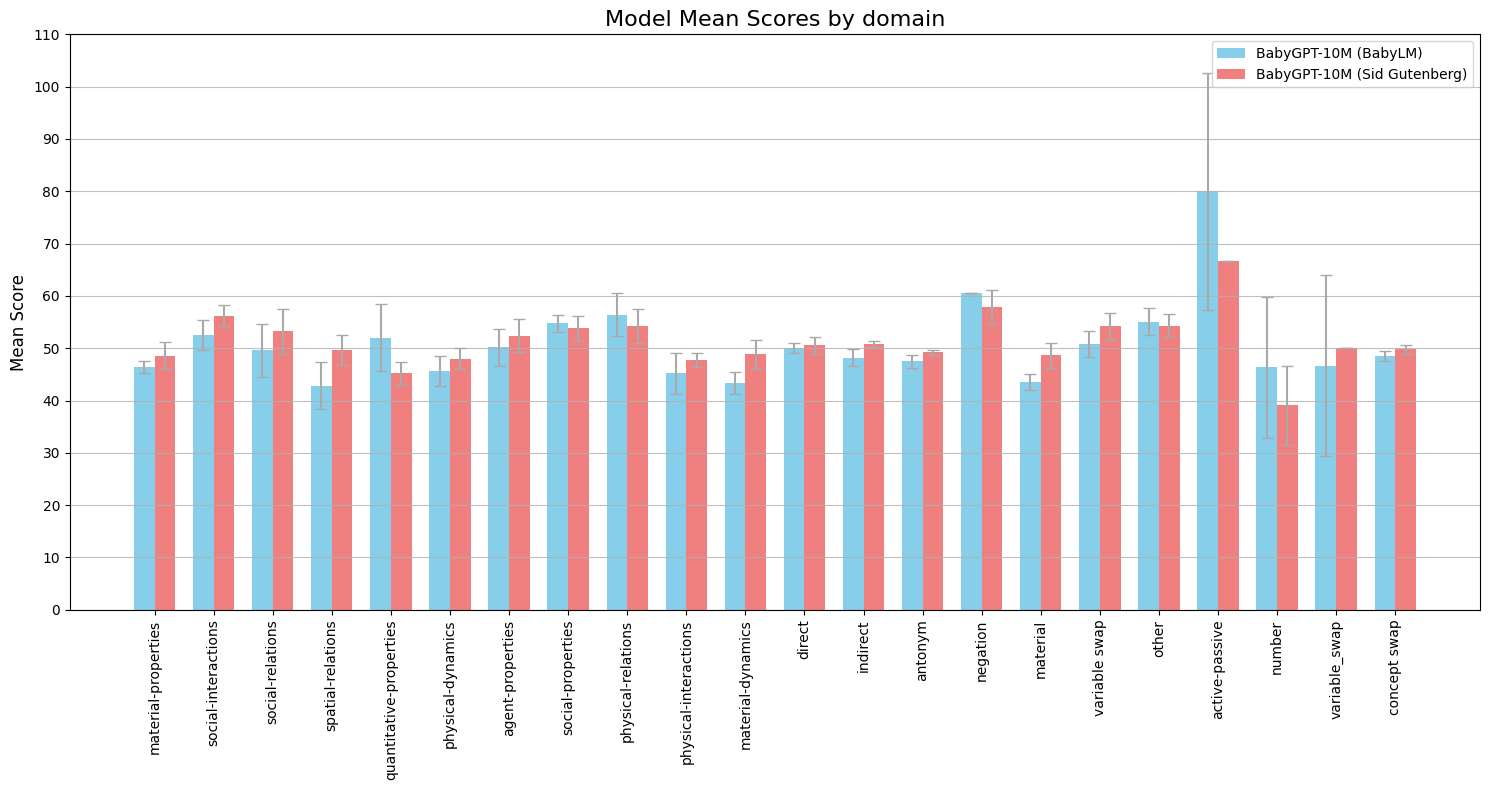

In [21]:
#we compare the confidence intervals with babylm gpt2 and the gutenberg trained gpt2 model
plot_scores_with_ci(total_accuracies, gutenberg_accuracies, model_1_label='BabyGPT-10M (BabyLM)', model_2_label='BabyGPT-10M (Sid Gutenberg)')

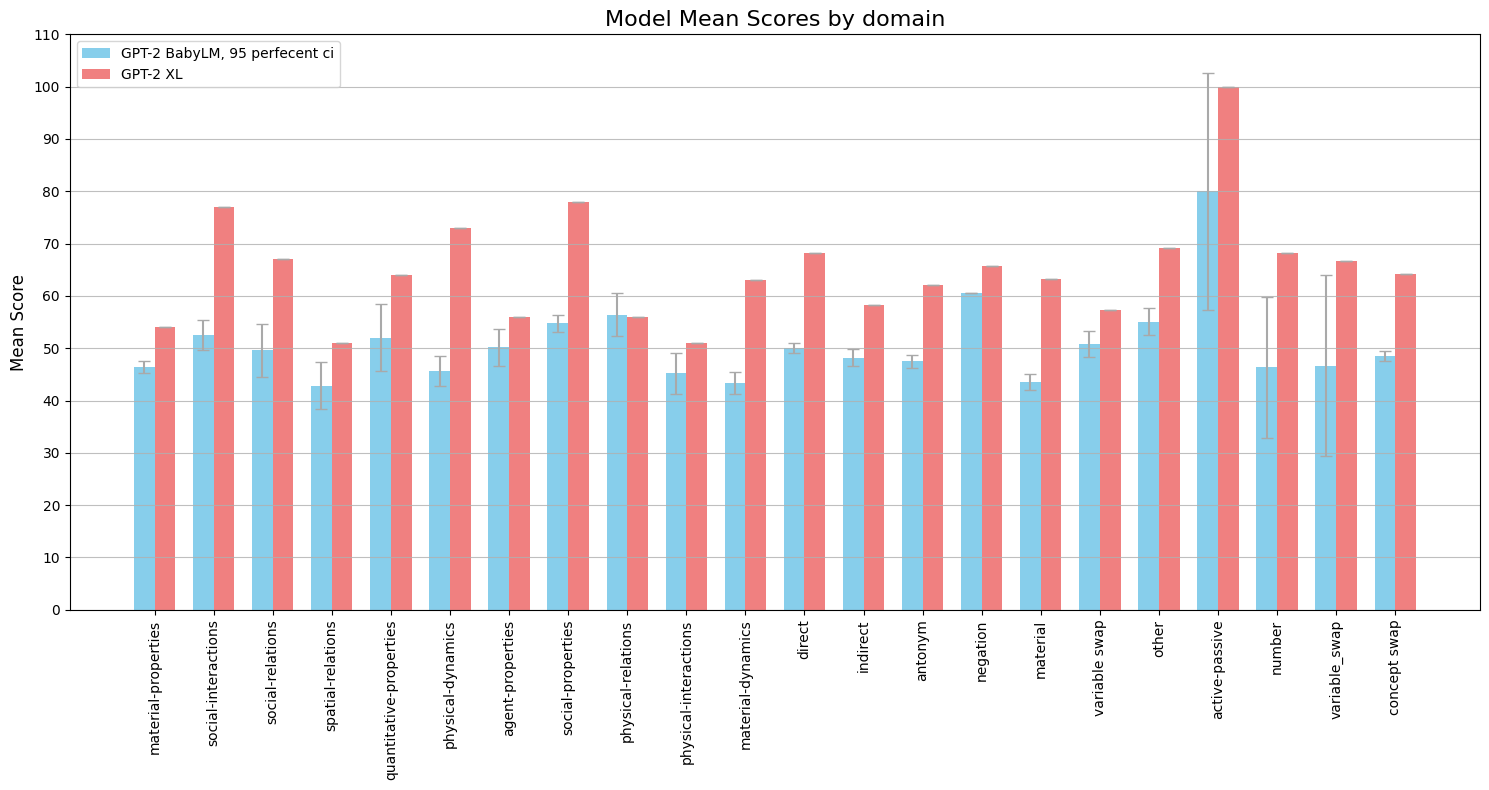

In [22]:
# Example usage:
plot_scores_with_ci(total_accuracies, gptxl_accuracies, model_1_label='GPT-2 BabyLM, 95 perfecent ci', model_2_label='GPT-2 XL')

In [5]:
# plot_scores_with_ci(phi_15_accuracies, gptxl_accuracies, model_1_label='Phi 1.5b', model_2_label='GPT-2 XL')

In [3]:
# # we compare the confidence intervals between the standard babylm GPT 2 and the larger hidden size
# plot_scores_with_ci(total_accuracies, large_hidden_accuracies, model_1_label='BabyGPT-10M (768*4)', model_2_label='BabyGPT-10M (Large Hidden Size (768*8))')

In [4]:
# #we plot the gpt 2 babylm model with the gpt 100m model
# plot_scores_with_ci(total_accuracies, gpt_100m_accuracies, model_1_label='BabyGPT-10M (BabyLM)', model_2_label='GPT-2 100M words')

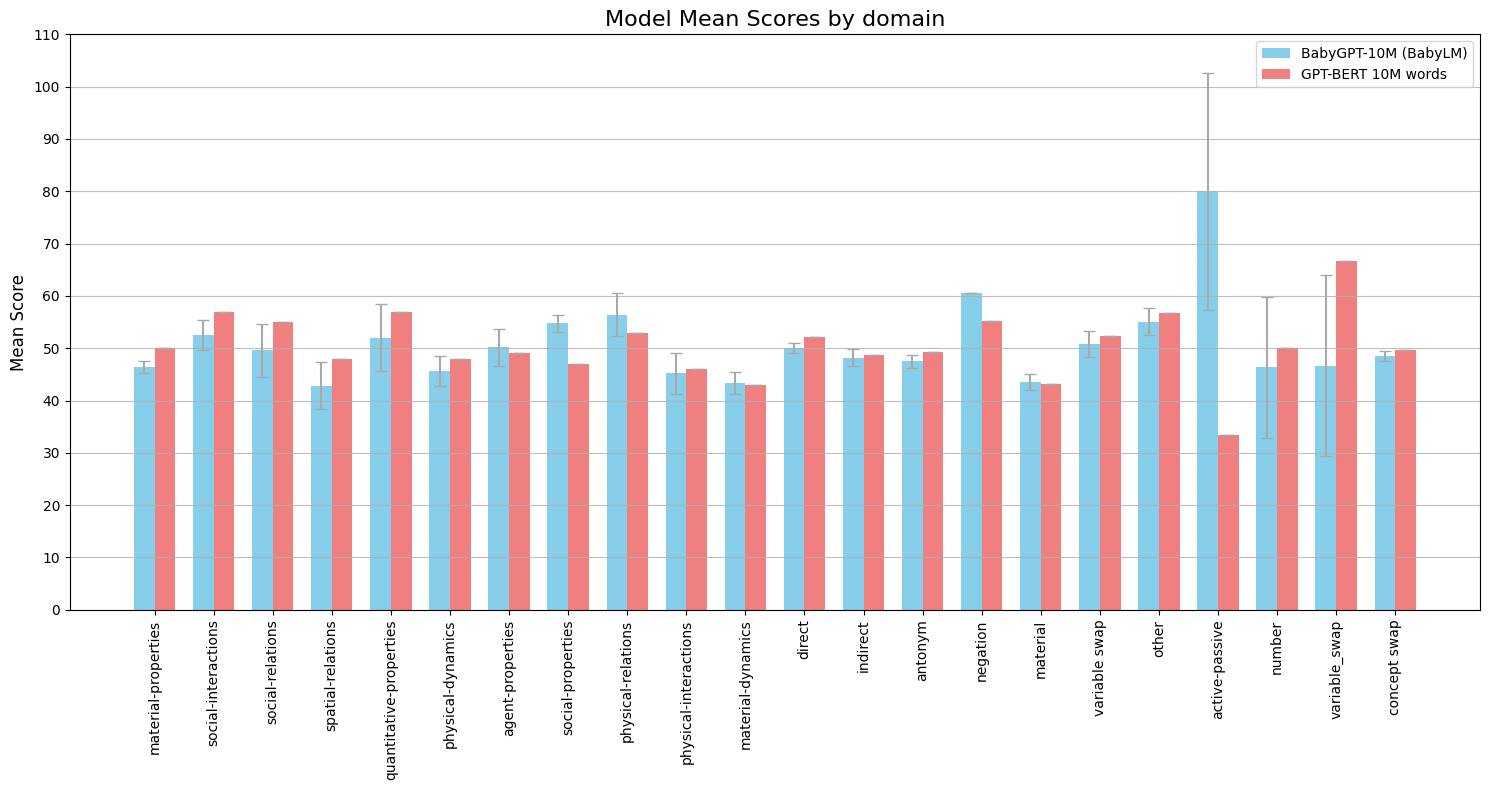

In [25]:
#we plot the gpt 2 babylm model with the gpt bert model
plot_scores_with_ci(total_accuracies, gpt_bert_accuracies, model_1_label='BabyGPT-10M (BabyLM)', model_2_label='GPT-BERT 10M words')

In [9]:
GPT_2_Small_report = """TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 52.00
social-interactions: 68.00
social-relations: 51.00
spatial-relations: 43.00
quantitative-properties: 54.00
physical-dynamics: 64.00
agent-properties: 46.00
social-properties: 61.00
physical-relations: 50.00
physical-interactions: 54.00
material-dynamics: 66.00

### CONTEXT_TYPE ACCURACY
direct: 59.88
indirect: 51.72

### CONTEXT_CONTRAST ACCURACY
antonym: 53.50
negation: 65.79
material: 63.31
variable swap: 51.18
other: 62.96
active-passive: 100.00
number: 45.45
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 57.16
variable swap: 48.46

### AVERAGE ACCURACY
55.36
"""
GPT_2_Small_accuracies = extract_accuracies(GPT_2_Small_report)
for k, v in GPT_2_Small_accuracies.items():
    GPT_2_Small_accuracies[k] = [GPT_2_Small_accuracies[k]]
    

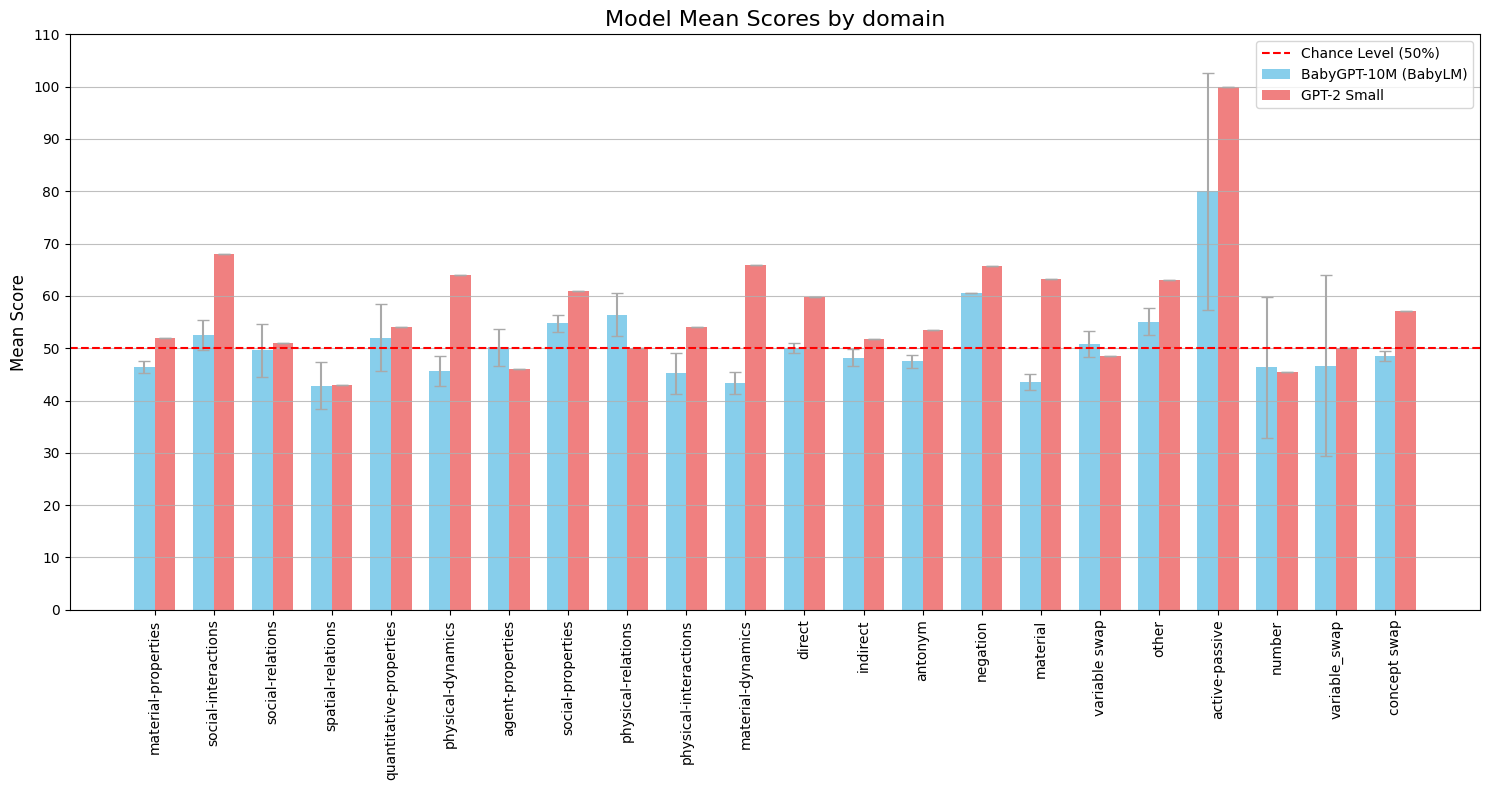

In [10]:
# we compare babylm gpt2 with gpt 2 small
plot_scores_with_ci(total_accuracies, GPT_2_Small_accuracies, model_1_label='BabyGPT-10M (BabyLM)', model_2_label='GPT-2 Small')

100%|██████████| 138/138 [00:04<00:00, 28.48it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 49.00
social-interactions: 55.00
social-relations: 50.00
spatial-relations: 45.00
quantitative-properties: 52.00
physical-dynamics: 53.00
agent-properties: 52.00
social-properties: 54.00
physical-relations: 51.00
physical-interactions: 48.00
material-dynamics: 51.00

### CONTEXT_TYPE ACCURACY
direct: 51.73
indirect: 50.25

### CONTEXT_CONTRAST ACCURACY
antonym: 50.50
negation: 55.26
material: 49.64
variable swap: 51.18
other: 54.32
active-passive: 33.33
number: 50.00
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 51.09
variable swap: 50.22

### AVERAGE ACCURACY
50.91


{'material-properties': 49.0, 'social-interactions': 55.0, 'social-relations': 50.0, 'spatial-relations': 45.0, 'quantitative-properties': 52.0, 'physical-dynamics': 53.0, 'agent-properties': 52.0, 'social-properties': 54.0, 'physical-relations': 51.0, 'physical-interactions': 48.0, 'material-dynamics': 51.0, 'direct': 51.73, 'indirect': 50.25, 'a

100%|██████████| 138/138 [00:04<00:00, 28.93it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 48.00
social-interactions: 56.00
social-relations: 51.00
spatial-relations: 45.00
quantitative-properties: 50.00
physical-dynamics: 49.00
agent-properties: 53.00
social-properties: 56.00
physical-relations: 52.00
physical-interactions: 45.00
material-dynamics: 47.00

### CONTEXT_TYPE ACCURACY
direct: 49.08
indirect: 51.07

### CONTEXT_CONTRAST ACCURACY
antonym: 49.67
negation: 63.16
material: 48.20
variable swap: 49.76
other: 54.32
active-passive: 33.33
number: 45.45
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 50.52
variable swap: 48.90

### AVERAGE ACCURACY
50.18


{'material-properties': 48.0, 'social-interactions': 56.0, 'social-relations': 51.0, 'spatial-relations': 45.0, 'quantitative-properties': 50.0, 'physical-dynamics': 49.0, 'agent-properties': 53.0, 'social-properties': 56.0, 'physical-relations': 52.0, 'physical-interactions': 45.0, 'material-dynamics': 47.0, 'direct': 49.08, 'indirect': 51.07, 'a

100%|██████████| 138/138 [00:04<00:00, 28.48it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 48.00
social-interactions: 57.00
social-relations: 50.00
spatial-relations: 46.00
quantitative-properties: 54.00
physical-dynamics: 56.00
agent-properties: 54.00
social-properties: 54.00
physical-relations: 57.00
physical-interactions: 49.00
material-dynamics: 51.00

### CONTEXT_TYPE ACCURACY
direct: 53.36
indirect: 51.56

### CONTEXT_CONTRAST ACCURACY
antonym: 51.67
negation: 55.26
material: 50.36
variable swap: 53.08
other: 56.79
active-passive: 33.33
number: 59.09
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 52.23
variable swap: 52.86

### AVERAGE ACCURACY
52.36


{'material-properties': 48.0, 'social-interactions': 57.0, 'social-relations': 50.0, 'spatial-relations': 46.0, 'quantitative-properties': 54.0, 'physical-dynamics': 56.0, 'agent-properties': 54.0, 'social-properties': 54.0, 'physical-relations': 57.0, 'physical-interactions': 49.0, 'material-dynamics': 51.0, 'direct': 53.36, 'indirect': 51.56, 'a

100%|██████████| 138/138 [00:04<00:00, 33.21it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 49.00
social-interactions: 55.00
social-relations: 52.00
spatial-relations: 51.00
quantitative-properties: 50.00
physical-dynamics: 50.00
agent-properties: 54.00
social-properties: 54.00
physical-relations: 52.00
physical-interactions: 49.00
material-dynamics: 49.00

### CONTEXT_TYPE ACCURACY
direct: 51.73
indirect: 51.07

### CONTEXT_CONTRAST ACCURACY
antonym: 51.17
negation: 63.16
material: 46.04
variable swap: 51.66
other: 55.56
active-passive: 66.67
number: 50.00
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 51.43
variable swap: 51.10

### AVERAGE ACCURACY
51.36


{'material-properties': 49.0, 'social-interactions': 55.0, 'social-relations': 52.0, 'spatial-relations': 51.0, 'quantitative-properties': 50.0, 'physical-dynamics': 50.0, 'agent-properties': 54.0, 'social-properties': 54.0, 'physical-relations': 52.0, 'physical-interactions': 49.0, 'material-dynamics': 49.0, 'direct': 51.73, 'indirect': 51.07, 'a

100%|██████████| 138/138 [00:03<00:00, 35.40it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 49.00
social-interactions: 55.00
social-relations: 46.00
spatial-relations: 44.00
quantitative-properties: 54.00
physical-dynamics: 52.00
agent-properties: 51.00
social-properties: 55.00
physical-relations: 48.00
physical-interactions: 51.00
material-dynamics: 49.00

### CONTEXT_TYPE ACCURACY
direct: 50.51
indirect: 50.25

### CONTEXT_CONTRAST ACCURACY
antonym: 50.00
negation: 60.53
material: 48.20
variable swap: 49.29
other: 55.56
active-passive: 33.33
number: 54.55
variable_swap: 33.33

### TARGET_CONTRAST ACCURACY
concept swap: 51.55
variable swap: 45.81

### AVERAGE ACCURACY
50.36


{'material-properties': 49.0, 'social-interactions': 55.0, 'social-relations': 46.0, 'spatial-relations': 44.0, 'quantitative-properties': 54.0, 'physical-dynamics': 52.0, 'agent-properties': 51.0, 'social-properties': 55.0, 'physical-relations': 48.0, 'physical-interactions': 51.0, 'material-dynamics': 49.0, 'direct': 50.51, 'indirect': 50.25, 'a

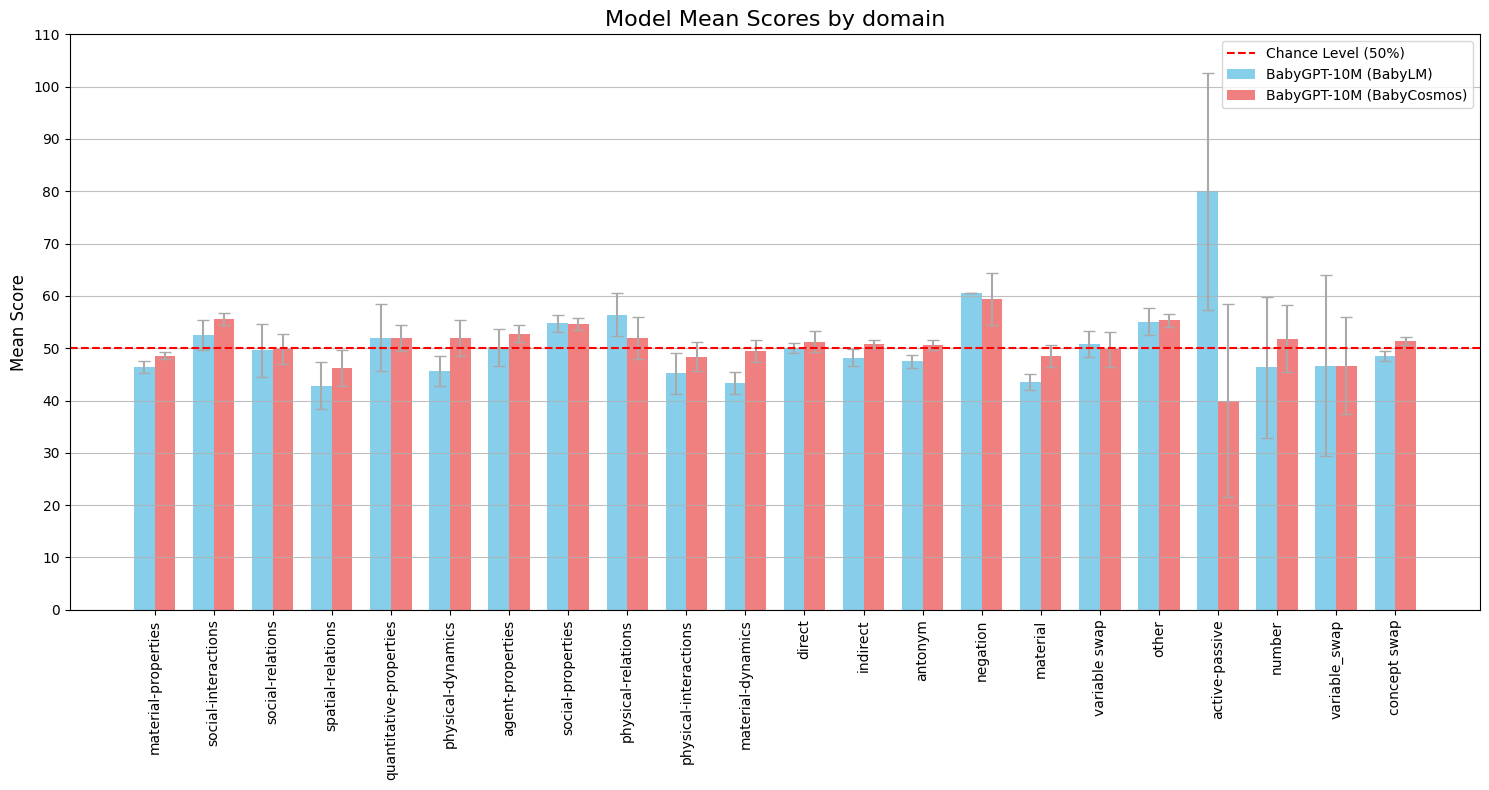

In [11]:
baby_cosmos_models = []
baby_cosmos_models.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_large_BBYCOSMO_16_19')
baby_cosmos_models.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_large_BBYCOSMO_16_57')
baby_cosmos_models.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_large_BBYCOSMO_16_79')
baby_cosmos_models.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_large_BBYCOSMO_16_121')
baby_cosmos_models.append('Jorgeis1/babygpt-10m-trial_run_Oc15th_BTSZ_large_BBYCOSMO_16_123')
#we try with baby cosmos trained models
baby_cosmos_accuracies = {}
#for each model in the list, we run the ewok evaluation
for model_path in baby_cosmos_models:
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(model_path)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.device

    args = SimpleNamespace(
        data_path=Path("/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/fast_eval/ewok_fast"),
        output_dir=Path("/tmp"),
        task="ewok",
        model_path_or_name=model_path,
        backend="causal",
        min_temperature=1.0,
        max_temperature=None,
        temperature_interval=0.05,
        batch_size=8,
        non_causal_batch_size=8,
        full_sentence_scores=False,
        save_predictions=False,
        revision_name="main",
    )

    model_name = model_path 


    dataloader = get_dataloader(args)
    temperatures = [1.0]
    results, _ = compute_results(args, model, dataloader, temperatures)
    accuracies, average_accuracies = process_results(args, results)

    # create_evaluation_report(1.0, average_accuracies[1.0], accuracies[1.0])
    #we try capturing the output
    val, out = capture_output(create_evaluation_report, 1.0, average_accuracies[1.0], accuracies[1.0])
    print(out)
    ewok_accuracies = extract_accuracies(out)

    print(ewok_accuracies)
    for k, v in ewok_accuracies.items():
        baby_cosmos_accuracies[f"{k}"] = baby_cosmos_accuracies.get(f"{k}", [])
        baby_cosmos_accuracies[f"{k}"].append( v)
plot_scores_with_ci(total_accuracies, baby_cosmos_accuracies, model_1_label='BabyGPT-10M (BabyLM)', model_2_label='BabyGPT-10M (BabyCosmos)')

In [1]:
# we consider a baby cosmos model with 20 epochs
baby_cosmos_20ep_models = ['Jorgeis1/babygpt-10m-trial_run_Oct_24_BBYCOSMO_16_121_epochs20']
baby_cosmos_20ep_accuracies = {}
for model_path in baby_cosmos_20ep_models:
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(model_path)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.device

    args = SimpleNamespace(
        data_path=Path("/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/fast_eval/ewok_fast"),
        output_dir=Path("/tmp"),
        task="ewok",
        model_path_or_name=model_path,
        backend="causal",
        min_temperature=1.0,
        max_temperature=None,
        temperature_interval=0.05,
        batch_size=8,
        non_causal_batch_size=8,
        full_sentence_scores=False,
        save_predictions=False,
        revision_name="main",
    )

    model_name = model_path 


    dataloader = get_dataloader(args)
    temperatures = [1.0]
    results, _ = compute_results(args, model, dataloader, temperatures)
    accuracies, average_accuracies = process_results(args, results)

    # create_evaluation_report(1.0, average_accuracies[1.0], accuracies[1.0])
    #we try capturing the output
    val, out = capture_output(create_evaluation_report, 1.0, average_accuracies[1.0], accuracies[1.0])
    print(out)
    ewok_accuracies = extract_accuracies(out)

    print(ewok_accuracies)
    for k, v in ewok_accuracies.items():
        baby_cosmos_20ep_accuracies[f"{k}"] = baby_cosmos_20ep_accuracies.get(f"{k}", [])
        baby_cosmos_20ep_accuracies [f"{k}"].append( v)
plot_scores_with_ci(total_accuracies, baby_cosmos_20ep_accuracies, model_1_label='BabyGPT-10M (BabyLM)', model_2_label='BabyGPT-10M (BabyCosmos 20 epochs)')

NameError: name 'AutoTokenizer' is not defined

In [7]:
model_paths = ['Jorgeis1/babygpt-10m-trial_run_Oct_24_CustomGemini_16_121_epochs10']
total_accuracies = {}

for model_path in model_paths:
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(model_path)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.device

    args = SimpleNamespace(
        data_path=Path("/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/fast_eval/ewok_fast"),
        output_dir=Path("/tmp"),
        task="ewok",
        model_path_or_name=model_path,
        backend="causal",
        min_temperature=1.0,
        max_temperature=None,
        temperature_interval=0.05,
        batch_size=64//2,
        non_causal_batch_size=64//2,
        full_sentence_scores=False,
        save_predictions=False,
        revision_name="main",
    )

    model_name = model_path 


    dataloader = get_dataloader(args)
    temperatures = [1.0]
    results, _ = compute_results(args, model, dataloader, temperatures)
    accuracies, average_accuracies = process_results(args, results)

    # create_evaluation_report(1.0, average_accuracies[1.0], accuracies[1.0])
    #we try capturing the output
    val, out = capture_output(create_evaluation_report, 1.0, average_accuracies[1.0], accuracies[1.0])
    print(out)

tokenizer_config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/131 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/793 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

100%|██████████| 35/35 [00:02<00:00, 13.91it/s]

TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 47.00
social-interactions: 50.00
social-relations: 46.00
spatial-relations: 43.00
quantitative-properties: 47.00
physical-dynamics: 43.00
agent-properties: 56.00
social-properties: 56.00
physical-relations: 56.00
physical-interactions: 43.00
material-dynamics: 41.00

### CONTEXT_TYPE ACCURACY
direct: 48.27
indirect: 47.78

### CONTEXT_CONTRAST ACCURACY
antonym: 45.50
negation: 60.53
material: 42.45
variable swap: 52.13
other: 58.02
active-passive: 66.67
number: 50.00
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 47.31
variable swap: 50.66

### AVERAGE ACCURACY
48.00


